# Previsão de Preço de Ações (BBAS3) com LSTM
**Banco do Brasil S.A. — Série histórica completa**

Este notebook realiza:
1. Coleta e limpeza de dados via `yfinance`
2. Análise Exploratória completa (EDA)
3. Testes estatísticos de estacionariedade
4. Modelagem com LSTM (Long Short-Term Memory)
5. Avaliação de desempenho e visualizações explicadas


## 1. Importações

In [43]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

import yfinance as yf

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import durbin_watson

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



## 2. Coleta de Dados

In [44]:
acao = yf.Ticker("BBAS3.SA")
df_raw = acao.history(period="27y")
df_raw.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-02:00,0.447984,0.456516,0.437317,0.437317,1029600,0.0,0.0
2000-01-04 00:00:00-02:00,0.437317,0.438384,0.416518,0.416518,628200,0.0,0.0
2000-01-05 00:00:00-02:00,0.415985,0.421318,0.401052,0.420785,957600,0.0,0.0
2000-01-06 00:00:00-02:00,0.420785,0.426651,0.415985,0.426651,410400,0.0,0.0
2000-01-07 00:00:00-02:00,0.426651,0.426651,0.417051,0.417051,788400,0.0,0.0


## 3. Limpeza dos Dados

Etapas:
- Resetar índice e manter colunas relevantes
- Converter datas e remover fuso horário
- Remover duplicatas, nulos, dias sem negociação e preços inconsistentes


In [45]:
# Reset de índice e seleção de colunas
df = df_raw.reset_index()[['Date','Open','High','Low','Close','Volume']]
df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
df = df.sort_values('Date').reset_index(drop=True)

# Duplicatas
df = df.drop_duplicates(subset='Date')

# Nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())
df = df.dropna()

# Dias sem negociação (Volume == 0)
n_sem_neg = (df['Volume'] == 0).sum()
print(f"\nDias sem negociação removidos: {n_sem_neg}")
df = df[df['Volume'] > 0]

# Preços inconsistentes (High < Close ou Low > Close)
tolerance = 1e-6
mask_inconsistente = (df['High'] + tolerance < df['Close']) | (df['Low'] - tolerance > df['Close'])
print(f"Preços inconsistentes removidos: {mask_inconsistente.sum()}")
df = df[~mask_inconsistente]


# Reset final
df = df.reset_index(drop=True)

print(f"\nTotal de registros após limpeza: {len(df)}")
print(f"Período: {df['Date'].min().date()} → {df['Date'].max().date()}")


Valores nulos por coluna:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Dias sem negociação removidos: 122
Preços inconsistentes removidos: 4

Total de registros após limpeza: 6445
Período: 2000-01-03 → 2026-03-06


## 4. Visão Geral do Dataset

In [46]:
print("Primeiras linhas:")
display(df.head())

print("\nEstatísticas descritivas:")
display(df[['Open','High','Low','Close','Volume']].describe().round(4))


Primeiras linhas:


,Date,Open,High,Low,Close,Volume
0,2000-01-03,0.447984,0.456516,0.437317,0.437317,1029600
1,2000-01-04,0.437317,0.438384,0.416518,0.416518,628200
2,2000-01-05,0.415985,0.421318,0.401052,0.420785,957600
3,2000-01-06,0.420785,0.426651,0.415985,0.426651,410400
4,2000-01-07,0.426651,0.426651,0.417051,0.417051,788400



Estatísticas descritivas:


,Open,High,Low,Close,Volume
count,6445.0000,6445.0000,6445.0000,6445.0000,6.445000e+03
mean,7.6031,7.7055,7.4968,7.6000,1.668555e+07
std,6.9197,6.9868,6.8495,6.9178,2.611495e+07
min,0.2933,0.3013,0.2832,0.2933,3.000000e+03
25%,2.5622,2.6116,2.5090,2.5583,4.863600e+06
50%,5.0825,5.1529,5.0194,5.0949,1.160100e+07
75%,10.9036,11.0706,10.7275,10.8810,2.032920e+07
max,28.7496,29.0201,28.5274,28.7496,6.408889e+08


## 5. Análise Exploratória (EDA)

### 5.1 Série Temporal do Preço de Fechamento

Permite identificar **tendências de longo prazo**, períodos de crise e crescimento do ativo.


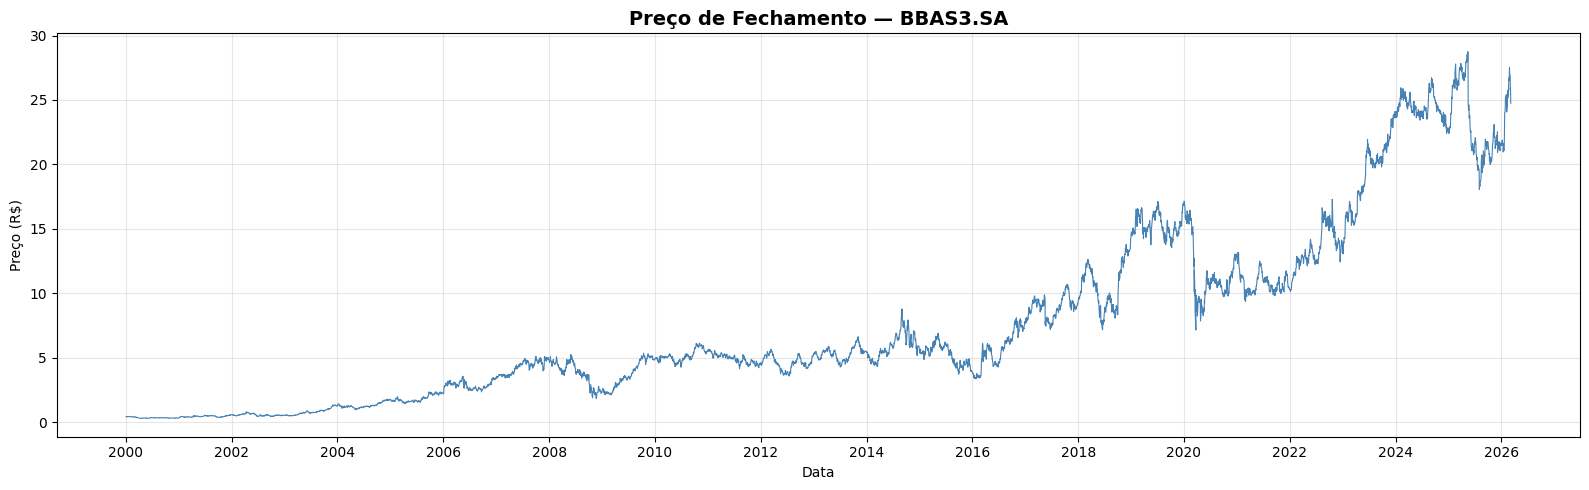


Interpretação:
- Tendência de alta de longo prazo com ciclos de crise visíveis.
- Quedas notáveis em 2008 (crise global), 2015-2016 (crise política/fiscal) e 2020 (COVID-19).
- Recuperação consistente após cada crise demonstra resiliência do ativo.



In [47]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['Date'], df['Close'], color='steelblue', linewidth=0.8)
ax.set_title('Preço de Fechamento — BBAS3.SA', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Preço (R$)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Interpretação:
- Tendência de alta de longo prazo com ciclos de crise visíveis.
- Quedas notáveis em 2008 (crise global), 2015-2016 (crise política/fiscal) e 2020 (COVID-19).
- Recuperação consistente após cada crise demonstra resiliência do ativo.
""")


### 5.2 Decomposição STL (Tendência, Sazonalidade e Resíduo)

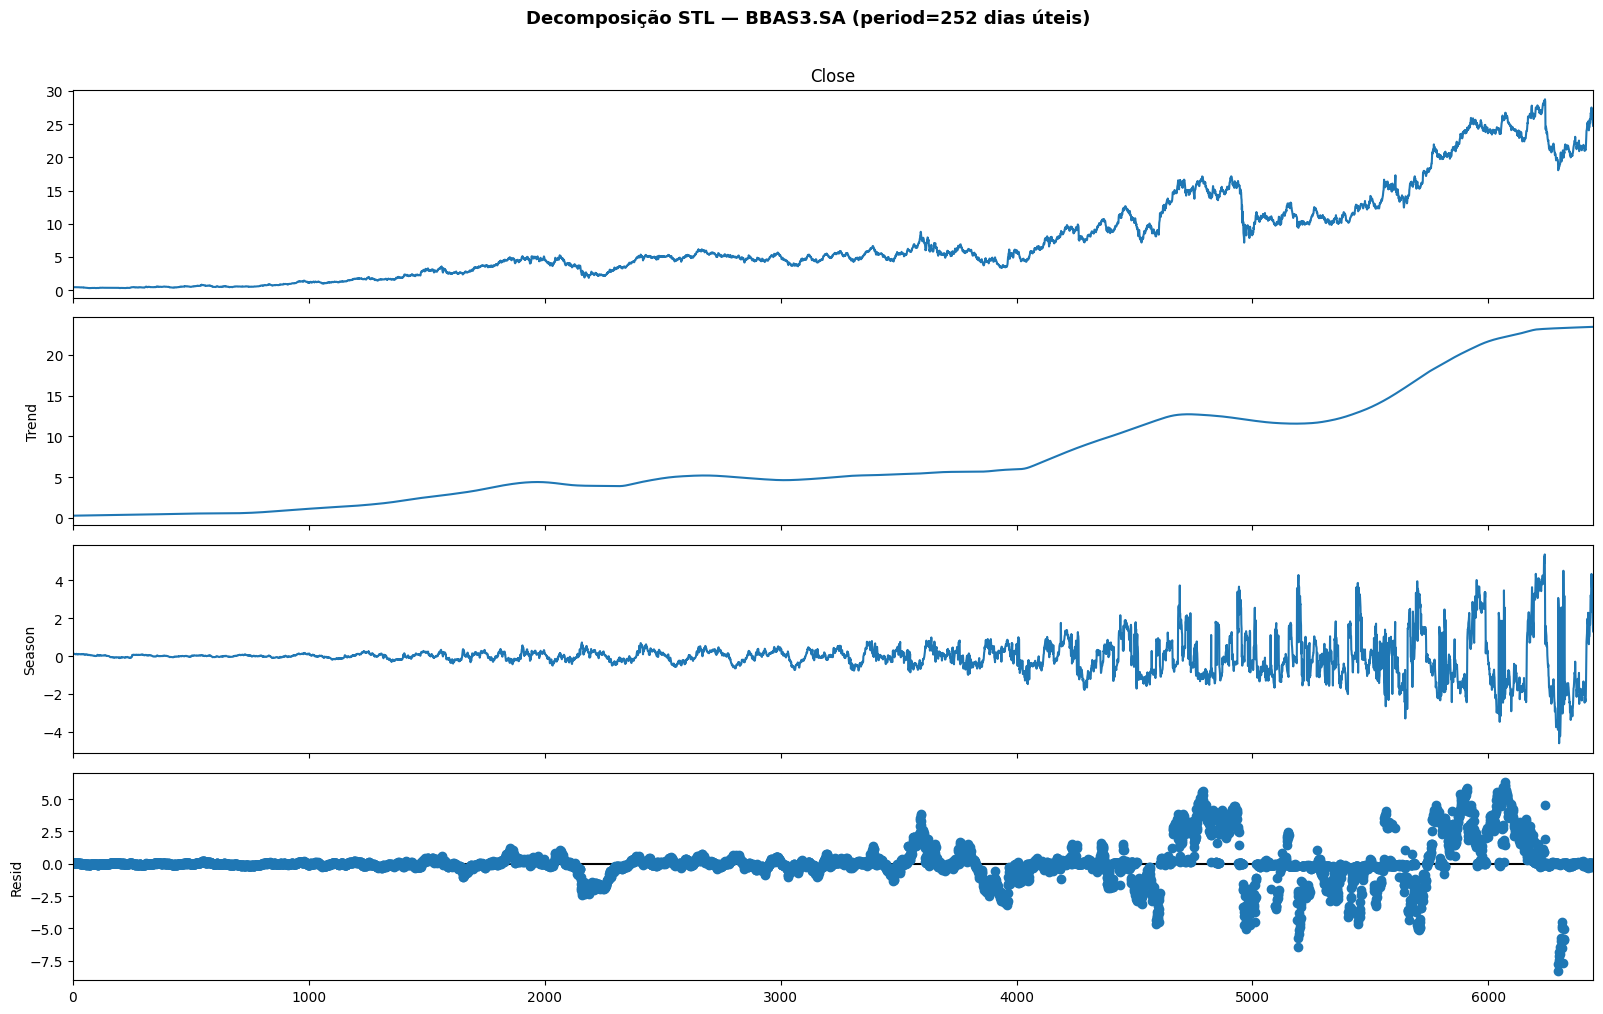

Força da tendência:    0.9595  (próximo de 1 = tendência dominante)
Força da sazonalidade: 0.0000  (próximo de 1 = padrão anual forte)

Interpretação:
- Tendência: componente de longo prazo da série (alta).
- Sazonalidade: padrão anual (252 dias úteis). Força baixa indica que os preços
  não seguem um ciclo anual fixo — típico de ações.
- Resíduo: parte não explicada pela tendência/sazonalidade — captura choques e crises.



In [48]:
stl = STL(df['Close'], period=252, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(16, 10)
fig.suptitle('Decomposição STL — BBAS3.SA (period=252 dias úteis)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Força da sazonalidade
var_resid = res.resid.var()
var_seasonal_resid = (res.seasonal + res.resid).var()
strength_seasonality = max(0, 1 - var_resid / var_seasonal_resid)

var_trend_resid = (res.trend + res.resid).var()
strength_trend = max(0, 1 - var_resid / var_trend_resid)

print(f"Força da tendência:    {strength_trend:.4f}  (próximo de 1 = tendência dominante)")
print(f"Força da sazonalidade: {strength_seasonality:.4f}  (próximo de 1 = padrão anual forte)")

print("""
Interpretação:
- Tendência: componente de longo prazo da série (alta).
- Sazonalidade: padrão anual (252 dias úteis). Força baixa indica que os preços
  não seguem um ciclo anual fixo — típico de ações.
- Resíduo: parte não explicada pela tendência/sazonalidade — captura choques e crises.
""")


### 5.6 Autocorrelação (ACF) e Autocorrelação Parcial (PACF)


Interpretação:
- O ACF mede o quanto o valor de hoje é parecido com o valor de dias atrás.
  No gráfico, cada barra representa um 'lag' (quantos dias atrás estamos olhando).
  Barras fora da faixa azul indicam que existe relação estatística entre os dias.

- ACF dos Preços: as barras demoram muitos lags para entrar na faixa azul.
  Isso significa que o preço de hoje ainda guarda relação com o preço de meses atrás.
  Esse decaimento lento é a assinatura de uma série não estacionária — a série
  tem tendência e não fica em torno de uma média fixa.




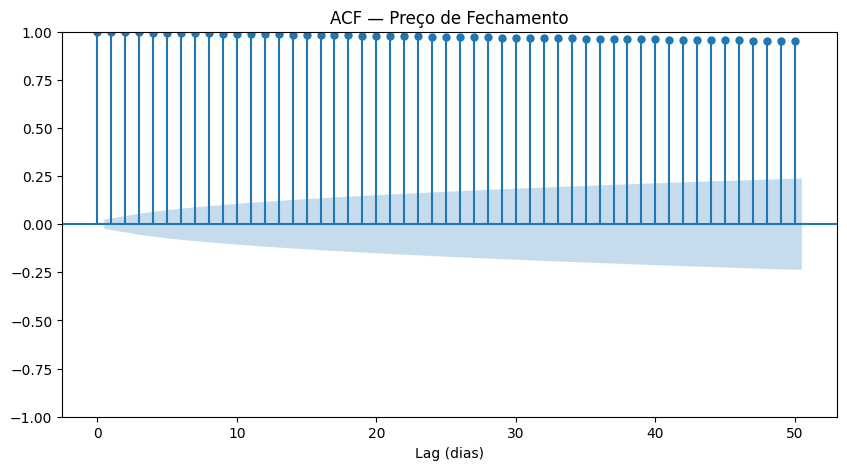

In [49]:
fig, axes = plt.subplots(1, figsize=(10, 5))

# ACF dos Preços
plot_acf(df['Close'], lags=50, ax=axes, title='ACF — Preço de Fechamento')
axes.set_xlabel('Lag (dias)')

print("""
Interpretação:
- O ACF mede o quanto o valor de hoje é parecido com o valor de dias atrás.
  No gráfico, cada barra representa um 'lag' (quantos dias atrás estamos olhando).
  Barras fora da faixa azul indicam que existe relação estatística entre os dias.

- ACF dos Preços: as barras demoram muitos lags para entrar na faixa azul.
  Isso significa que o preço de hoje ainda guarda relação com o preço de meses atrás.
  Esse decaimento lento é a assinatura de uma série não estacionária — a série
  tem tendência e não fica em torno de uma média fixa.

""")



Interpretação:
- PACF dos Preços: o PACF mede a correlação direta entre o preço de hoje e o
  de X dias atrás, removendo o efeito dos dias intermediários.
  Se a barra do lag 1 é alta e as demais caem rapidamente, isso indica que
  o preço de ontem é o que mais influencia o preço de hoje — os dias mais
  distantes só importam indiretamente (através da cadeia de dias consecutivos).
  Isso é típico de séries com tendência e ajuda a justificar o uso de
  janelas de 20 a 60 dias no LSTM: o sinal relevante está nos dias recentes.



Text(0.5, 0, 'Lag (dias)')

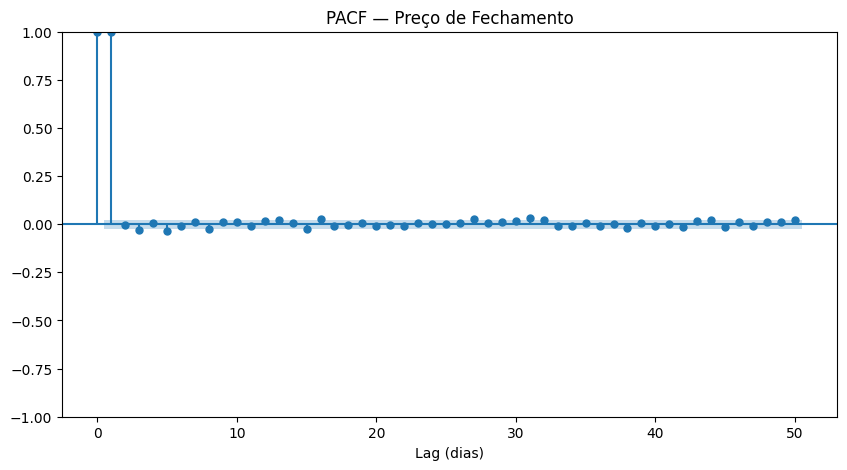

In [50]:
print("""
Interpretação:
- PACF dos Preços: o PACF mede a correlação direta entre o preço de hoje e o
  de X dias atrás, removendo o efeito dos dias intermediários.
  Se a barra do lag 1 é alta e as demais caem rapidamente, isso indica que
  o preço de ontem é o que mais influencia o preço de hoje — os dias mais
  distantes só importam indiretamente (através da cadeia de dias consecutivos).
  Isso é típico de séries com tendência e ajuda a justificar o uso de
  janelas de 20 a 60 dias no LSTM: o sinal relevante está nos dias recentes.
""")

fig, axes = plt.subplots(1, figsize=(10, 5))

# PACF dos Preços
plot_pacf(df['Close'], lags=50, ax=axes, title='PACF — Preço de Fechamento')
axes.set_xlabel('Lag (dias)')


## 6. Teste de Estacionariedade

Séries financeiras raramente são estacionárias. Verificamos formalmente com dois testes:
- **ADF (Augmented Dickey-Fuller)**: H₀ = série tem raiz unitária (não estacionária)
- **KPSS**: H₀ = série é estacionária


In [51]:
def teste_estacionariedade(serie, nome):
    print(f"{'='*55}")
    print(f"  Série: {nome}")
    print(f"{'='*55}")

    # ADF
    adf_res = adfuller(serie.dropna(), autolag='AIC')
    print(f"\n[ADF] Estatística: {adf_res[0]:.4f} | p-valor: {adf_res[1]:.6f}")
    if adf_res[1] < 0.05:
        print("  → ESTACIONÁRIA (rejeita H₀ de raiz unitária)")
    else:
        print("  → NÃO ESTACIONÁRIA (não rejeita H₀)")

    # KPSS
    kpss_res = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f"\n[KPSS] Estatística: {kpss_res[0]:.4f} | p-valor: {kpss_res[1]:.6f}")
    if kpss_res[1] > 0.05:
        print("  → ESTACIONÁRIA (não rejeita H₀ de estacionariedade)")
    else:
        print("  → NÃO ESTACIONÁRIA (rejeita H₀)")
    print()

teste_estacionariedade(df['Close'], 'Preço de Fechamento')

print("""
Interpretação:
- Estacionariedade significa que a série tem média e variância estáveis ao longo do tempo —
  ela não tem tendência de subir ou cair indefinidamente.
- O teste ADF verifica se a série tem 'raiz unitária' (sinal de não estacionariedade).
  P-valor abaixo de 0.05 → série estacionária. Acima → não estacionária.
- O teste KPSS faz o contrário: assume que a série É estacionária e tenta refutar isso.
  P-valor abaixo de 0.05 → não estacionária.

- Para o Preço de Fechamento: ambos os testes devem apontar NÃO estacionária.
  Faz sentido: o preço do BBAS3 em 1997 era muito diferente do preço em 2024 —
  ele tem uma tendência clara de crescimento no longo prazo.

""")


  Série: Preço de Fechamento

[ADF] Estatística: -0.1425 | p-valor: 0.945042
  → NÃO ESTACIONÁRIA (não rejeita H₀)

[KPSS] Estatística: 9.9978 | p-valor: 0.010000
  → NÃO ESTACIONÁRIA (rejeita H₀)


Interpretação:
- Estacionariedade significa que a série tem média e variância estáveis ao longo do tempo —
  ela não tem tendência de subir ou cair indefinidamente.
- O teste ADF verifica se a série tem 'raiz unitária' (sinal de não estacionariedade).
  P-valor abaixo de 0.05 → série estacionária. Acima → não estacionária.
- O teste KPSS faz o contrário: assume que a série É estacionária e tenta refutar isso.
  P-valor abaixo de 0.05 → não estacionária.

- Para o Preço de Fechamento: ambos os testes devem apontar NÃO estacionária.
  Faz sentido: o preço do BBAS3 em 1997 era muito diferente do preço em 2024 —
  ele tem uma tendência clara de crescimento no longo prazo.
 



## 7. Preparação dos Dados para o LSTM

### Estratégia:
1. Usar apenas o preço de fechamento (`Close`) — abordagem univariada
2. Normalização com `MinMaxScaler` [0, 1]
3. Divisão temporal: 80% treino / 20% teste (sem embaralhar — ordem importa!)
4. Criação de janelas deslizantes com `look_back = 60` dias


In [52]:
# Parâmetro de janela temporal
'''
Justificativa para usar 60 dias: Um artigo de 2025 investigou especificamente os fatores que influenciam o LSTM
em previsão de ações e concluiu que janelas temporais excessivamente longas ou curtas reduzem a performance preditiva do modelo.
https://dl.acm.org/doi/10.1145/3700906.3700964
'''
LOOK_BACK = 60  # quantos dias anteriores o modelo observa para prever o próximo

# Selecionar apenas Close
close_values = df['Close'].values.reshape(-1, 1)

# Divisão treino/teste (temporal — não embaralhar!)
train_size = int(len(close_values) * 0.8)
train_data = close_values[:train_size]
test_data  = close_values[train_size - LOOK_BACK:]

# Normalização
scaler = MinMaxScaler(feature_range=(0,1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(f"Total de amostras:    {len(close_values)}")
print(f"Amostras de treino:   {train_size}")
print(f"Amostras de teste:    {len(close_values) - train_size}")
print(f"Janela (look_back):   {LOOK_BACK} dias")

# Função para criar sequências (X, y)
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOK_BACK)
X_test,  y_test  = create_sequences(test_scaled,  LOOK_BACK)

# Reshape para [amostras, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print(f"\nShape X_train: {X_train.shape}")
print(f"Shape X_test:  {X_test.shape}")


Total de amostras:    6445
Amostras de treino:   5156
Amostras de teste:    1289
Janela (look_back):   60 dias

Shape X_train: (5096, 60, 1)
Shape X_test:  (1289, 60, 1)


## 8. Construção do Modelo LSTM

### Arquitetura:
- **2 camadas LSTM** com Dropout para regularização
- **1 camada Dense** de saída
- Optimizer: Adam | Loss: MSE


In [53]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(units=100, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(units=100, return_sequences=False),
    Dropout(0.2),
    Dense(units=50, activation='relu'),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,301 (493.36 KB)

 Trainable params: 126,301 (493.36 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Treinamento

In [54]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - loss: 0.0081 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - loss: 7.1752e-04 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - loss: 4.8474e-04 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - loss: 4.5137e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 4.4418e-04 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - loss: 4.0066e-04 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - loss: 3.6450e-04 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 3.0812e-04 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 9/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 2.9739

### 9.1 Curva de Aprendizado

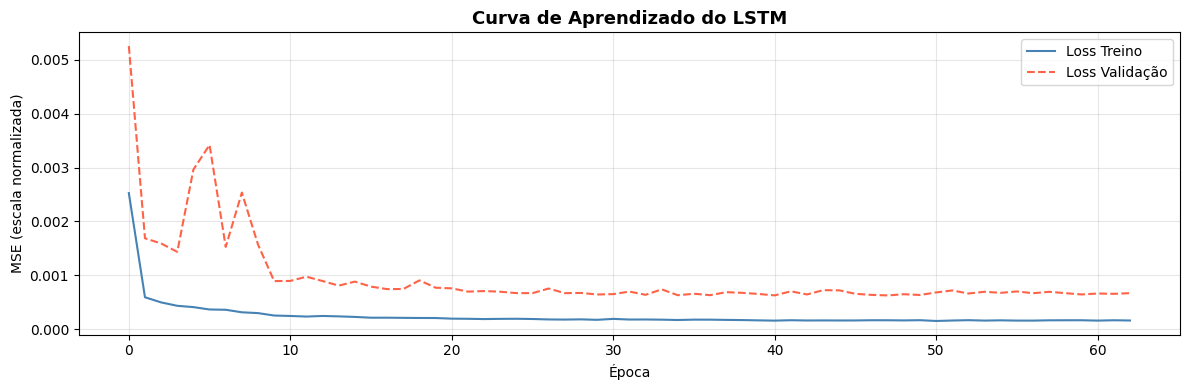


Interpretação:
- O gráfico mostra como o erro do modelo foi diminuindo a cada época de treinamento.
- A linha azul é o erro nos dados de treino (os dados que o modelo viu).
  A linha vermelha é o erro na validação (dados que o modelo NÃO viu durante o treino).

- O que esperamos ver: as duas linhas caindo juntas e se estabilizando próximas.
  Isso indica que o modelo aprendeu padrões reais, não apenas decorou os dados.

- Sinal de alerta — Overfitting: se a linha azul continua caindo mas a vermelha
  começa a subir, o modelo está 'decorando' o treino e perdendo capacidade de
  generalizar para dados novos. É como um aluno que só decora as questões antigas
  mas não entende o conteúdo de verdade.

- O Dropout (20%) ajuda a evitar overfitting 'apagando' aleatoriamente neurônios
  durante o treino, forçando o modelo a aprender representações mais robustas.

- O Early Stopping monitora a linha vermelha e para o treinamento automaticamente
  quando ela para de melhorar — salvando os pesos 

In [55]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history.history['loss'],     label='Loss Treino',   color='steelblue')
ax.plot(history.history['val_loss'], label='Loss Validação', color='tomato', linestyle='--')
ax.set_title('Curva de Aprendizado do LSTM', fontsize=13, fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('MSE (escala normalizada)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Interpretação:
- O gráfico mostra como o erro do modelo foi diminuindo a cada época de treinamento.
- A linha azul é o erro nos dados de treino (os dados que o modelo viu).
  A linha vermelha é o erro na validação (dados que o modelo NÃO viu durante o treino).

- O que esperamos ver: as duas linhas caindo juntas e se estabilizando próximas.
  Isso indica que o modelo aprendeu padrões reais, não apenas decorou os dados.

- Sinal de alerta — Overfitting: se a linha azul continua caindo mas a vermelha
  começa a subir, o modelo está 'decorando' o treino e perdendo capacidade de
  generalizar para dados novos. É como um aluno que só decora as questões antigas
  mas não entende o conteúdo de verdade.

- O Dropout (20%) ajuda a evitar overfitting 'apagando' aleatoriamente neurônios
  durante o treino, forçando o modelo a aprender representações mais robustas.

- O Early Stopping monitora a linha vermelha e para o treinamento automaticamente
  quando ela para de melhorar — salvando os pesos do melhor momento encontrado.
  Isso evita treinar além do ponto ótimo.
""")


## 12. Visualizações dos Resultados

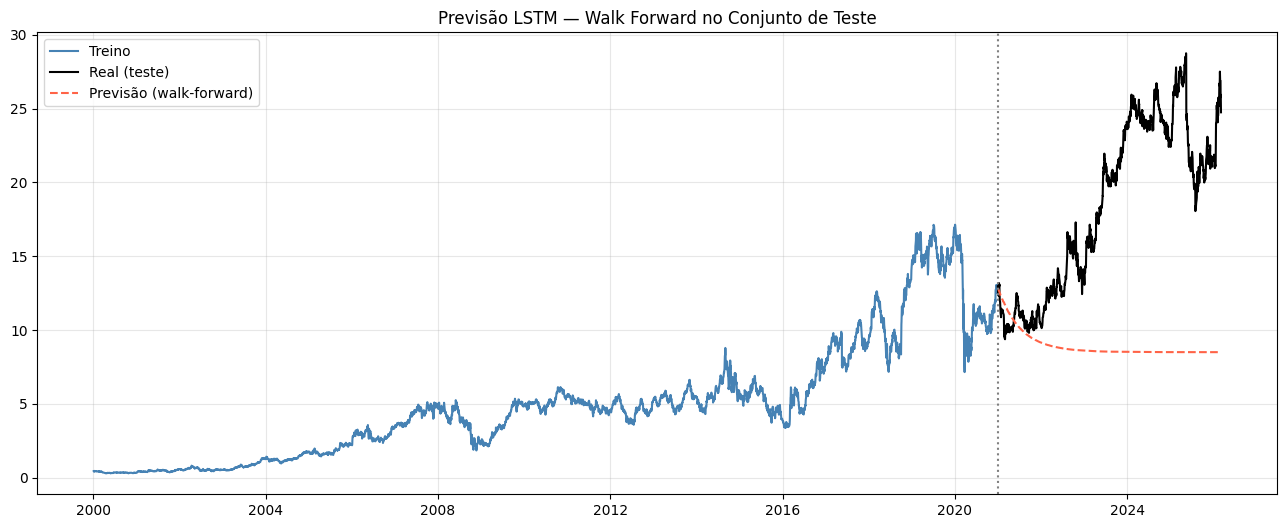

In [57]:
# -----------------------------------------
# Previsão do conjunto de teste (walk-forward)
# -----------------------------------------

N_TEST = len(close_values) - train_size

# começar com os últimos LOOK_BACK do treino
ultimo_bloco = train_scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)

previsoes_teste = []
bloco_atual = ultimo_bloco.copy()

for _ in range(N_TEST):

    pred = model.predict(bloco_atual, verbose=0)
    previsoes_teste.append(pred[0, 0])

    # deslizar janela adicionando a previsão
    bloco_atual = np.append(
        bloco_atual[:, 1:, :],
        pred.reshape(1, 1, 1),
        axis=1
    )

# desnormalizar
previsoes_teste = scaler.inverse_transform(
    np.array(previsoes_teste).reshape(-1, 1)
)

# valores reais do teste
real_teste = close_values[train_size:]
datas_teste = df['Date'].values[train_size:]

fig, ax = plt.subplots(figsize=(16,6))

# treino
ax.plot(df['Date'].values[:train_size],
        close_values[:train_size],
        label="Treino",
        color="steelblue")

# real teste
ax.plot(datas_teste,
        real_teste,
        label="Real (teste)",
        color="black")

# previsão teste
ax.plot(datas_teste,
        previsoes_teste,
        label="Previsão (walk-forward)",
        color="tomato",
        linestyle="--")

ax.axvline(df['Date'].values[train_size], color='gray', linestyle=':')

ax.set_title("Previsão LSTM — Walk Forward no Conjunto de Teste")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 13. Previsão de Dias Futuros

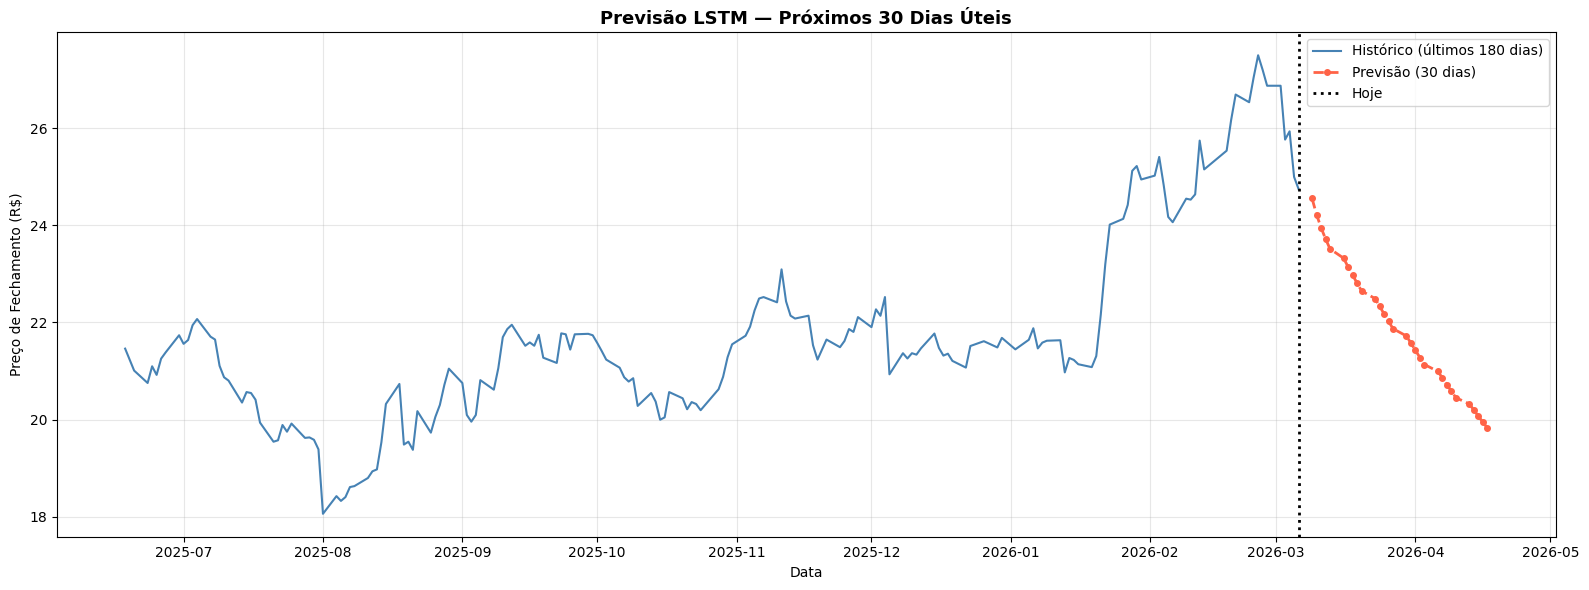

Último preço real: R$ 24.75
Previsão para D+1: R$ 24.56
Previsão para D+30: R$ 19.82


In [59]:
N_DIAS_FUTURO = 30  # quantos dias à frente prever

# Usar os últimos LOOK_BACK dias reais como ponto de partida
ultimo_bloco = test_scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)

previsoes_futuras = []
bloco_atual = ultimo_bloco.copy()

for _ in range(N_DIAS_FUTURO):
    pred = model.predict(bloco_atual, verbose=0)
    previsoes_futuras.append(pred[0, 0])
    # deslizar a janela: remover o mais antigo, adicionar o previsto
    bloco_atual = np.append(bloco_atual[:, 1:, :], pred.reshape(1, 1, 1), axis=1)

# Desnormalizar
previsoes_futuras = scaler.inverse_transform(np.array(previsoes_futuras).reshape(-1, 1))

# Datas futuras (dias úteis)
ultima_data = df['Date'].max()
datas_futuras = pd.bdate_range(start=ultima_data + pd.Timedelta(days=1), periods=N_DIAS_FUTURO)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'].values[-180:], close_values[-180:], label='Histórico (últimos 180 dias)', color='steelblue')
ax.plot(datas_futuras, previsoes_futuras, label=f'Previsão ({N_DIAS_FUTURO} dias)', color='tomato', linewidth=2, linestyle='--', marker='o', markersize=4)
ax.axvline(x=ultima_data, color='black', linestyle=':', linewidth=2, label='Hoje')
ax.set_title(f'Previsão LSTM — Próximos {N_DIAS_FUTURO} Dias Úteis', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Preço de Fechamento (R$)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Último preço real: R$ {close_values[-1][0]:.2f}")
print(f"Previsão para D+1: R$ {previsoes_futuras[0][0]:.2f}")
print(f"Previsão para D+{N_DIAS_FUTURO}: R$ {previsoes_futuras[-1][0]:.2f}")

